<a href="https://colab.research.google.com/github/Sanika-tech123/Deep-Learning-Lab/blob/main/DL_6_Classifying_Reuters.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

2110848/2110848 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Dataset Loaded Successfully
Training Data: 8982
Testing Data: 2246


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/8
15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 73ms/step - accuracy: 0.3393 - loss: 3.3251 - val_accuracy: 0.4802 - val_loss: 2.5399
Epoch 2/8
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - accuracy: 0.5770 - loss: 2.0028 - val_accuracy: 0.6761 - val_loss: 1.6246
Epoch 3/8
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step - accuracy: 0.6970 - loss: 1.3790 - val_accuracy: 0.7156 - val_loss: 1.3399
Epoch 4/8
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step - accuracy: 0.7585 - loss: 1.0954 - val_accuracy: 0.7418 - val_loss: 1.1950
Epoch 5/8
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step - accuracy: 0.8053 - loss: 0.8980 - val_accuracy: 0.7563 - val_loss: 1.1125
Epoch 6/8
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 70ms/step - accuracy: 0.8468 - loss: 0.7379 - val_accuracy: 0.7613 - val_loss: 1.0562
Epoch 7/8
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 86ms/step - accuracy: 0.8788 - loss: 0.5995 - val_accuracy: 0.7930 - val_loss: 0.9982
Epoch 8/8
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 70ms/step - accuracy: 0.9019 - loss: 0.4914 - val_accuracy: 0.7863 - val_loss:

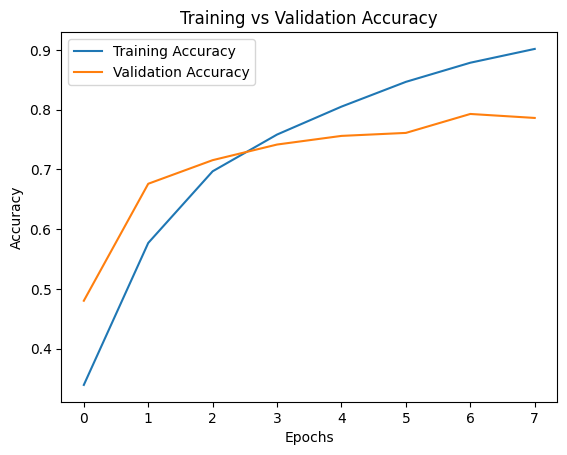

In [ ]:
# Import libraries
import tensorflow as tf
from tensorflow.keras.datasets import reuters
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt

# ---------------------------------------------------
# Load Reuters Dataset
# ---------------------------------------------------

# Use top 10000 most common words
(X_train, y_train), (X_test, y_test) = reuters.load_data(num_words=10000)

print("Dataset Loaded Successfully")

print("Training Data:", len(X_train))
print("Testing Data:", len(X_test))

# ---------------------------------------------------
# Convert Text Data into Vector Format
# ---------------------------------------------------

def vectorize_sequences(sequences, dimension=10000):

    results = tf.zeros((len(sequences), dimension))

    results = results.numpy()

    for i, sequence in enumerate(sequences):
        results[i, sequence] = 1.

    return results

X_train = vectorize_sequences(X_train)
X_test = vectorize_sequences(X_test)

# ---------------------------------------------------
# Convert Labels into Categorical Format
# ---------------------------------------------------

y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

# ---------------------------------------------------
# Build Deep Neural Network
# ---------------------------------------------------

model = Sequential()

model.add(Dense(64, activation='relu', input_shape=(10000,)))

model.add(Dense(64, activation='relu'))

model.add(Dense(46, activation='softmax'))

# ---------------------------------------------------
# Compile Model
# ---------------------------------------------------

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# ---------------------------------------------------
# Train Model
# ---------------------------------------------------

history = model.fit(
    X_train,
    y_train,
    epochs=8,
    batch_size=512,
    validation_split=0.2
)

# ---------------------------------------------------
# Evaluate Model
# ---------------------------------------------------

results = model.evaluate(X_test, y_test)

print("\nTest Loss:", results[0])
print("Test Accuracy:", results[1])

# ---------------------------------------------------
# Plot Accuracy Graph
# ---------------------------------------------------

plt.plot(history.history['accuracy'], label='Training Accuracy')

plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Training vs Validation Accuracy")

plt.xlabel("Epochs")

plt.ylabel("Accuracy")

plt.legend()

plt.show()